# GlobalFit-EGC: demo

Los **ciclos generadores de energía** (EGCs) son conjuntos de reacciones que, en
un modelo metabólico, cargan ATP (u otro metabolito energético) **sin consumir
nutrientes**. Son termodinámicamente imposibles, pero FBA no lo sabe: los usa
felizmente y el crecimiento predicho se infla.

Este notebook muestra el pipeline completo sobre *E. coli* iJO1366:

1. **Detectar** EGCs para los 15 metabolitos energéticos de Fritzemeier et al. (2017).
2. **Corregir** con GlobalFit: el mínimo de direcciones de reacción a eliminar.
3. **Priorizar** entre soluciones empatadas con pesos por evidencia genómica.
4. **Validar** contra los resultados publicados del paper.

In [1]:
import pandas as pd

from globalfit import (
    add_energy_dissipation_reactions,
    detect_egcs,
    evidence_weights,
    globalfit,
    load_bigg_model,
    verify,
)

MODELOS = "../modelos"  # caché local de modelos de BiGG
pd.set_option("display.max_colwidth", None)

## 1. Detección

iJO1366 está curado: sus autores bloquearon seis reacciones que formaban EGCs.
Para recrear el problema, las reactivamos.

A cada modelo se le agregan las **reacciones de disipación de energía** (EDR) de
la tabla S1 del paper, p. ej. `ATP + H2O → ADP + Pi + H+`. Después se bloquea la
captación de todos los nutrientes y se maximiza cada EDR: si alguna puede llevar
flujo, el modelo fabrica esa energía de la nada.

In [2]:
model = load_bigg_model("iJO1366", MODELOS)
edrs = add_energy_dissipation_reactions(model)
print(f"{len(edrs)} reacciones de disipación agregadas")

curado = detect_egcs(model, edrs, normalize=True)
crecimiento_curado = model.slim_optimize()

EGC_REACTIONS = ["SPODM", "SPODMpp", "SUCASPtpp", "SUCFUMtpp", "SUCMALtpp", "SUCTARTtpp"]
for rid in EGC_REACTIONS:
    model.reactions.get_by_id(rid).bounds = (-1000, 1000)

con_egc = detect_egcs(model, edrs, normalize=True)
crecimiento_egc = model.slim_optimize()

pd.DataFrame({"curado": curado, "6 reacciones reactivadas": con_egc}).rename(
    index=lambda r: r.removeprefix("EDR_")
).T

15 reacciones de disipación agregadas


,ATP,CTP,GTP,UTP,ITP,NADH,NADPH,FADH2,FMNH2,Q8H2,MQL8,DMMQL8,ACCOA,GLU,PROTON
curado,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
6 reacciones reactivadas,0.75,0.75,0.75,0.75,0.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.75,0.0,3.0


Sin nutrientes, el modelo curado no genera nada. Con las seis reacciones
reactivadas, genera ATP, otros nucleótidos trifosfato, acetil-CoA y un gradiente
de protones. (Con `normalize=True` cada reacción se acota a flujo 1, así que el
valor refleja cuánto rinde cada ciclo por vuelta.)

Eso se nota en el crecimiento predicho:

In [3]:
print(f"Crecimiento curado:      {crecimiento_curado:.3f} 1/h")
print(f"Crecimiento con EGCs:    {crecimiento_egc:.3f} 1/h  "
      f"(+{crecimiento_egc / crecimiento_curado - 1:.0%})")

Crecimiento curado:      0.982 1/h
Crecimiento con EGCs:    1.389 1/h  (+41%)


## 2. Corrección con GlobalFit

GlobalFit busca el conjunto mínimo de **direcciones** de reacción a eliminar
($\delta$ binarias) tal que:

- **caso de crecimiento:** el modelo sigue produciendo biomasa $\ge T$;
- **caso sin crecimiento:** sin nutrientes, $\max \sum_d v_d = 0$ sobre las EDR.

El segundo es un problema de optimización *dentro* de otro (binivel). Como es un
LP, se reemplaza por su **certificado dual**: existe $(\lambda, \alpha, \beta)$ con

$$S^\top \lambda + \alpha - \beta = c, \qquad \alpha_j \le M\,\delta^F_j, \qquad \beta_j \le M\,\delta^B_j$$

donde $\lambda$ actúa como un "potencial químico" por metabolito. Queda un solo
MILP, que HiGHS resuelve sin licencia. Cada solución se verifica después con un
FBA independiente.

In [4]:
def tabla(results):
    filas = []
    for r in results:
        energia, crecimiento = verify(model, r.removals, edrs)
        filas.append({
            "costo": r.objective,
            "eliminar": ", ".join(map(str, r.removals)),
            "EGCs tras corregir": sum(v > 0 for v in energia.values()),
            "crecimiento": round(crecimiento, 3),
        })
    return pd.DataFrame(filas)

uniforme = globalfit(model, energy_rxns=edrs, n_solutions=5)
tabla(uniforme)

,costo,eliminar,EGCs tras corregir,crecimiento
0,1.0,MDH (forward),0,0.966
1,1.0,SPODM (forward),0,0.982
2,1.0,MOX (backward),0,0.982
3,2.0,"QMO2 (forward), QMO3 (forward)",0,0.982
4,2.0,"NADH17pp (forward), QMO2 (forward)",0,0.992


Basta **un cambio**, pero hay tres soluciones empatadas. Las tres eliminan
todos los EGCs, pero no valen lo mismo biológicamente: `MDH` es la malato
deshidrogenasa del ciclo de Krebs y quitarla baja el crecimiento.

## 3. Pesos por evidencia

El paper sugiere dos criterios para desempatar:

- las reacciones **sin gen asociado** (sin GPR) tienen menos respaldo genómico y
  deberían ser más baratas de eliminar;
- es más probable que sobre **una dirección de una reacción reversible** que una
  reacción irreversible completa.

`evidence_weights` implementa ambos (por defecto: ×0,5 sin gen, ×2 irreversible).

In [5]:
for rid in ["MOX", "MDH", "SPODM"]:
    r = model.reactions.get_by_id(rid)
    print(f"{rid:6s} {r.name:28s} GPR: {r.gene_reaction_rule or '(ninguno)'}")

ponderado = globalfit(model, energy_rxns=edrs, weights=evidence_weights(model), n_solutions=3)
tabla(ponderado)

MOX    Malate oxidase               GPR: (ninguno)
MDH    Malate dehydrogenase         GPR: b3236
SPODM  Superoxide dismutase         GPR: b3908 or b1656


,costo,eliminar,EGCs tras corregir,crecimiento
0,0.5,MOX (backward),0,0.982
1,1.0,SPODM (forward),0,0.982
2,1.0,MDH (forward),0,0.966


Con pesos, **`MOX` (malato oxidasa) queda como la única solución óptima**:
es la única de las tres sin gen asociado. Coincide con lo que el paper
argumenta por termodinámica (la reacción inversa de MOX es muy desfavorable),
pero aquí sale solo de la anotación del modelo.

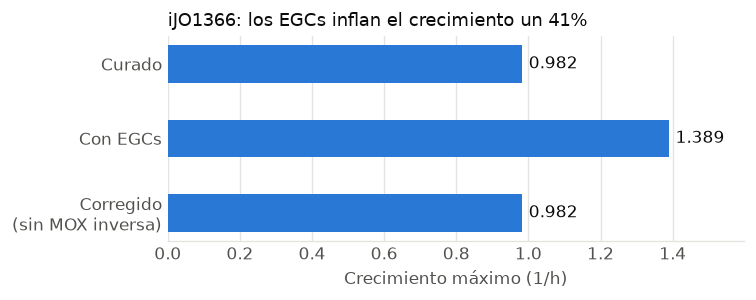

In [6]:
import matplotlib.pyplot as plt

crecimiento_corregido = verify(model, ponderado[0].removals, edrs)[1]
etiquetas = ["Curado", "Con EGCs", "Corregido\n(sin MOX inversa)"]
valores = [crecimiento_curado, crecimiento_egc, crecimiento_corregido]

TINTA, TINTA_2, GRILLA, SERIE = "#0b0b0b", "#52514e", "#e4e3df", "#2a78d6"
fig, ax = plt.subplots(figsize=(6.4, 2.6), dpi=120)
barras = ax.barh(etiquetas, valores, color=SERIE, height=0.5)
ax.invert_yaxis()
ax.bar_label(barras, fmt="%.3f", padding=4, color=TINTA, fontsize=10)
ax.set_xlim(0, max(valores) * 1.15)
ax.set_xlabel("Crecimiento máximo (1/h)", color=TINTA_2)
ax.set_title("iJO1366: los EGCs inflan el crecimiento un "
             f"{crecimiento_egc / crecimiento_curado - 1:.0%}", loc="left", color=TINTA, fontsize=11)
ax.tick_params(colors=TINTA_2, length=0)
ax.grid(axis="x", color=GRILLA, linewidth=0.8)
ax.set_axisbelow(True)
for lado in ["top", "right", "left"]:
    ax.spines[lado].set_visible(False)
ax.spines["bottom"].set_color(GRILLA)
plt.tight_layout()
plt.show()

## 4. Validación contra el paper

La tabla S2 del paper lista, para cada modelo con EGCs, qué detectó y qué
eliminó GlobalFit. De los tres modelos de BiGG que el paper reporta con EGCs,
aquí van los dos con correcciones pequeñas (el tercero, iRC1080, requiere ~50
cambios y queda pendiente). Los modelos se descargan hoy y pueden diferir
levemente de las versiones de 2015. Seguimos los métodos del paper:
crecimiento en medio rico y una segunda corrida que no permite eliminar la ATP
sintasa.

In [7]:
PAPER = {
    "iND750": {"detecta": "ACCOA 1", "simple": "ACOAH (forward)", "sin tocar ATP sintasa": "ACOAH (forward)"},
    "iJN746": {"detecta": "ATP 1, CTP 1, GTP 1, UTP 1, ACCOA 1, PROTON 4",
               "simple": "ACALD (forward)", "sin tocar ATP sintasa": "ALDD2x_copy2 (backward)"},
}
SINTASAS = ["ATPS4rpp", "ATPS4r", "ATPS3m", "ATPS3v"]

filas = []
for nombre, paper in PAPER.items():
    m = load_bigg_model(nombre, MODELOS)
    e = add_energy_dissipation_reactions(m)
    detectado = ", ".join(f"{k.removeprefix('EDR_')} {v:g}"
                          for k, v in detect_egcs(m, e, normalize=True).items() if v > 0)
    filas.append({"modelo": nombre, "": "paper", **paper})
    nuestro = {"detecta": detectado}
    for corrida, protegidas in [("simple", []), ("sin tocar ATP sintasa", SINTASAS)]:
        rs = globalfit(m, energy_rxns=e, rich_medium=True, min_growth=0.01,
                       protected=[r for r in protegidas if r in m.reactions], n_solutions=3)
        nuestro[corrida] = " | ".join(", ".join(map(str, r.removals)) for r in rs)
    filas.append({"modelo": nombre, "": "GlobalFit-EGC", **nuestro})

pd.DataFrame(filas).set_index(["modelo", ""])

detecta  \
modelo                                                                
iND750 paper                                                ACCOA 1   
       GlobalFit-EGC                                        ACCOA 1   
iJN746 paper          ATP 1, CTP 1, GTP 1, UTP 1, ACCOA 1, PROTON 4   
       GlobalFit-EGC  ATP 1, CTP 1, GTP 1, UTP 1, ACCOA 1, PROTON 4   

                                                         simple  \
modelo                                                            
iND750 paper                                    ACOAH (forward)   
       GlobalFit-EGC                            ACOAH (forward)   
iJN746 paper                                    ACALD (forward)   
       GlobalFit-EGC  ALDD2x_copy2 (backward) | ACALD (forward)   

                                          sin tocar ATP sintasa  
modelo                                                           
iND750 paper                                    ACOAH (forward)  
       GlobalFit-EGC                            ACOAH (forward)  
iJN746 paper                            ALDD2x_copy2 (backward)  
       GlobalFit-EGC  ALDD2x_copy2 (backward) | ACALD (forward)

La detección coincide número por número y la eliminación que reporta el paper
aparece siempre entre nuestras soluciones óptimas. (En iJN746 hay dos
alternativas de un cambio; el paper reporta una por corrida.)

## 5. ¿Por qué mirar más que ATP?

En el modelo core de *E. coli* agregamos una reacción errónea:
`oaa + 2 H+ → mal`, una reducción sin donante de electrones. Junto con la malato
deshidrogenasa forma un ciclo que fabrica NADH de la nada, y desde ahí la red
lo convierte en quinol, NADPH, glutamato y, vía la ATP sintasa, en ATP.

¿Qué pasa si GlobalFit solo vigila el ATP?

In [8]:
from cobra import Reaction
from cobra.io import load_model

core = load_model("textbook")
falsa = Reaction("FAKE_OAA", lower_bound=0, upper_bound=1000)
core.add_reactions([falsa])
falsa.add_metabolites({core.metabolites.oaa_c: -1, core.metabolites.h_c: -2,
                       core.metabolites.mal__L_c: 1})
e_core = add_energy_dissipation_reactions(core)

filas = []
for vigila, energia in [("solo ATP", "EDR_ATP"), ("las 15 EDR", e_core)]:
    [r] = globalfit(core, energy_rxns=energia)
    restante, crecimiento = verify(core, r.removals, e_core)
    filas.append({
        "vigila": vigila,
        "elimina": ", ".join(map(str, r.removals)),
        "EGCs que quedan": ", ".join(k.removeprefix("EDR_") for k, v in restante.items() if v > 0) or "ninguno",
        "crecimiento": round(crecimiento, 3),
    })
pd.DataFrame(filas)

,vigila,elimina,EGCs que quedan,crecimiento
0,solo ATP,ATPS4r (forward),"NADH, NADPH, Q8H2, GLU",0.374
1,las 15 EDR,FAKE_OAA (forward),ninguno,0.874


Vigilando solo ATP, GlobalFit corta el **síntoma**: elimina la ATP sintasa,
el crecimiento cae a menos de la mitad y el ciclo de NADH sigue vivo. Vigilando
los 15 metabolitos energéticos, corta la **causa**: la reacción errónea.